In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys

sys.path.insert(1,"../src/")

In [4]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import scipy.signal as sp

import acoustic_inversion as ai

In [5]:
# [Title, Freq, ssp, bdry, pos, beam, cint, rmax] = at.read_env("feif_scenario.env", "KRAKEN")

In [6]:
SAMPLING_FREQ = 2000
TRUE_SOUNDSPEED = 1460

FREQ_RANGE = [250, 400]

In [7]:
with np.load("../data/output/warping_arrival_times.npz", allow_pickle=True ) as file1:
    data1 = dict(mode_nos = file1['mode_nos'], peaks_coordinates=file1['peaks_coordinates'])

replicas = scipy.io.loadmat("../data/field_values20260707/field_values20260707.mat")
data1['mode_nos'] = data1['mode_nos'] - 1

f = replicas['f'].squeeze()
f_Vg = f[1:-1]
c = replicas['soundspeed'].squeeze()
Vg = replicas['Vg'].squeeze()
Vg = Vg[data1['mode_nos'].squeeze()]
receiver_range = replicas['range'][0,0]*1e3

nmodes, nspeed, nfreq = Vg.shape

In [8]:
Vg.shape

(4, 29, 299)

In [9]:
#data1['peaks_coordinates'] = [ M for M in data1['peaks_coordinates'][0]]

In [10]:
f_mask = np.array([f_Vg >= FREQ_RANGE[0],f_Vg <= FREQ_RANGE[1]]).all(0)
regression_f = f_Vg[f_mask]

In [11]:
coefs = np.array([np.polyfit(d[:,0], d[:,1], 2) for d in data1['peaks_coordinates']])
arrival_times_data = np.array([np.polyval(c, regression_f) for c in coefs])

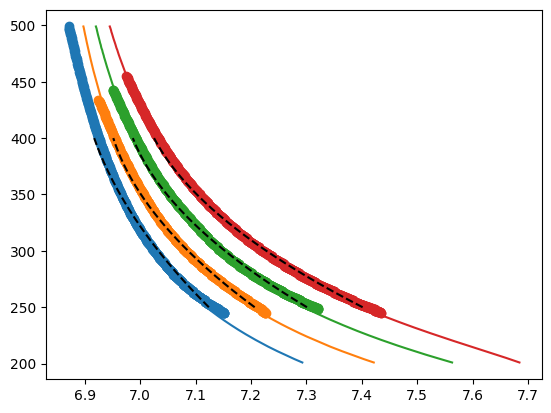

In [12]:
fig, ax = plt.subplots()

for p in data1['peaks_coordinates']:
    ax.scatter(p[:,1], p[:,0])
    
ax.plot(receiver_range/Vg[:, c==TRUE_SOUNDSPEED,:].squeeze().T, f_Vg)
ax.set_prop_cycle(None)
ax.plot(arrival_times_data.T, regression_f, ls='--', c='k')

#ax.set_xlim([6.65, 7.75])

In [13]:
#arrival_times_data = receiver_range/Vg[:, c == TRUE_SOUNDSPEED, ...]
arrival_times_replica = receiver_range/Vg[...,f_mask].transpose([1,0,2])

## Direct dispersion

In [14]:
l1 = ai.AcousticInversionLikelihood(arrival_times_data)

In [15]:
likelihood_direct = l1.likelihood_direct(arrival_times_replica, 1e-2)

Text(0, 0.5, 'Likelihood')

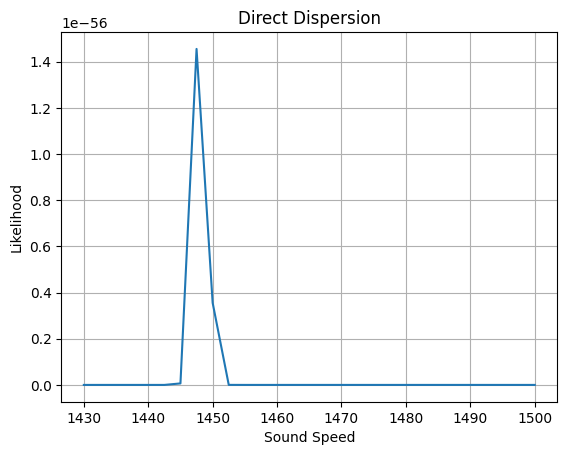

In [16]:
fig, ax = plt.subplots()

ax.plot(c, likelihood_direct)
ax.grid()


ax.set_title(f'Direct Dispersion')
ax.set_xlabel('Sound Speed')
ax.set_ylabel('Likelihood')

In [17]:
likelihood_intramodal = l1.likelihood_intramodal(arrival_times_replica)

In [18]:
likelihood = l1.likelihood(arrival_times_replica, 1e-1)

Text(0, 0.5, 'Likelihood')

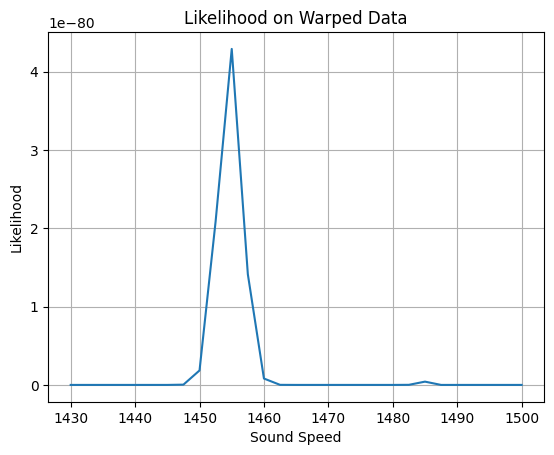

In [21]:
fig, ax = plt.subplots()
ax.plot(c, likelihood)
ax.grid()

ax.set_title("Likelihood on Warped Data")

ax.set_xlabel("Sound Speed")
ax.set_ylabel("Likelihood")

In [22]:
fig.savefig("likelihood on warped.png", dpi=600)